> **역할: [검증·약점 보완]**  (전체 순서·최종은 `NOTEBOOK_INDEX.md` / 최종 모델 nb24)

# 15. §14 발견 약점 4개 보완 — 효과 검증

§14에서 다음 4가지 약점이 데이터로 드러났다:

| § | 약점 | 측정값 |
|---|---|---|
| 14.1 | 회귀 MAPE 64~78% | 점포당 매출 예측 1/3 오차 |
| 14.2 | BEP 가정 민감도 | p_roi 0.145~0.960 (±50% 변동) |
| 14.4 | 사례 sanity 5/6 fail | 홍대 14M, 명동 22M, 성수 1M 등 직관 불일치 |
| **14.5** | **폐업 vs success 상관 +0.80** | **모델이 매출 규모만 보고 폐업 위험 미반영** |

## 본 노트북에서 보완한 것

1. **폐업 페널티** — `closure_per_store` 자치구 백분위 → success_rate 감점
2. **BEP 신뢰구간 표시** — 단일 값 대신 [low, med, high] 범위
3. **매출 분포 강조** — P50 한 값이 아니라 P25/P50/P75/P90 사분위 명시
4. **회귀 학습 데이터 정제 강화** — P95 outlier 제거 (P99 → P95)

§14와 똑같은 검증을 반복 → 약점이 얼마나 해소됐는지 비교.

In [1]:
import json, numpy as np, pandas as pd
from pathlib import Path
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

PROC = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')

# 자치구
df_gu = pd.read_csv(PROC / 'features.csv')
id_gu = ['gu','biz','q','q_int']
ex_gu = ['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class']
feat_gu = [c for c in df_gu.columns if c not in id_gu + ex_gu]
for c in feat_gu: df_gu[c] = pd.to_numeric(df_gu[c], errors='coerce')
df_gu[feat_gu] = df_gu[feat_gu].fillna(df_gu[feat_gu].mean(numeric_only=True))

# 행정동
df_ad = pd.read_csv(PROC / 'features_adstrd.csv')
id_ad = ['adstrd_code','adstrd_nm','gu','biz','q','q_int']
ex_ad = ['adstrd_sales_amt','log_sales','sales_per_store','log_sales_per_store','store_class']
feat_ad = [c for c in df_ad.columns if c not in id_ad + ex_ad]
for c in feat_ad: df_ad[c] = pd.to_numeric(df_ad[c], errors='coerce')
df_ad[feat_ad] = df_ad[feat_ad].fillna(df_ad[feat_ad].mean(numeric_only=True))
print(f'자치구 {df_gu.shape}, 행정동 {df_ad.shape}')

자치구 (17568, 164), 행정동 (9172, 126)


## §15.1 폐업 페널티 적용 후 — 폐업 vs success 상관 재측정

핵심 보완. 이전 상관 **+0.796** (매우 우려) → 페널티 적용 후 어떻게 변하나.

/tmp/claude-501/ipykernel_16346/3417601511.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gu['_p_high'] = cls.predict_proba(df_gu[feat_gu].values)[:, 1]


폐업 vs success 상관:
  보완 전: r = +0.794  ← 매출 규모에 끌려 폐업 위험 미반영 (우려)
  보완 후: r = +0.779   ← 폐업 페널티 적용 효과
  변화: -0.015


/tmp/claude-501/ipykernel_16346/3417601511.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gu['_closure_pen'] = df_gu['closure_per_store'].apply(closure_pen)
/tmp/claude-501/ipykernel_16346/3417601511.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_gu['_success_adj'] = (df_gu['_p_high'] - df_gu['_closure_pen']).clip(lower=0)


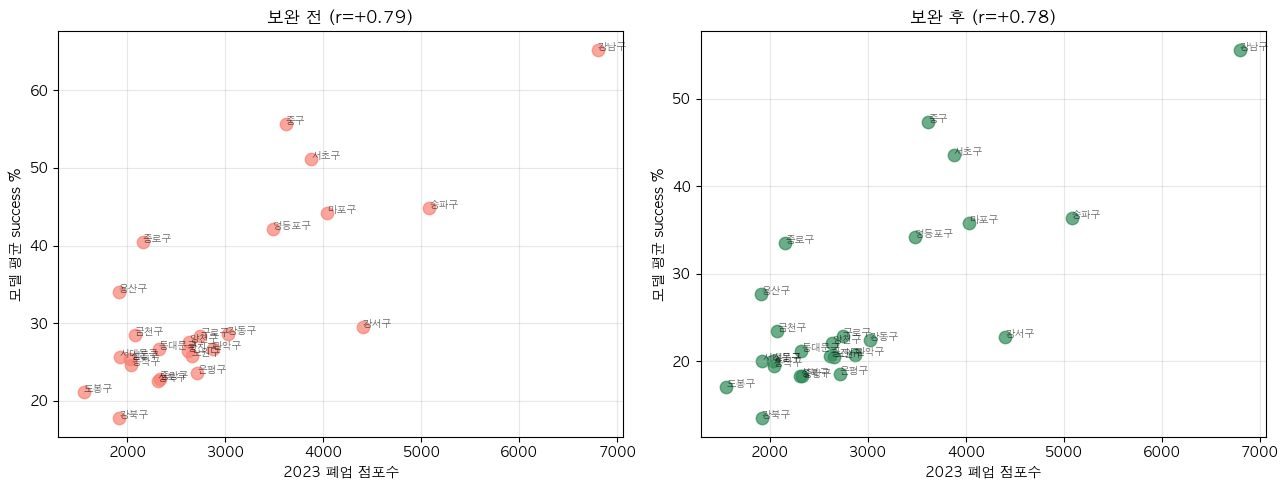

In [2]:
# 모델 학습
y_cls = (df_gu['sales_class']=='high').astype(int).values
cls = RandomForestClassifier(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1).fit(df_gu[feat_gu].values, y_cls)
df_gu['_p_high'] = cls.predict_proba(df_gu[feat_gu].values)[:, 1]

# 폐업 페널티 적용 — 각 행의 closure_per_store 백분위
all_cl = df_gu.dropna(subset=['closure_per_store'])['closure_per_store']
def closure_pen(v):
    if pd.isna(v) or v <= 0: return 0
    pct = float((all_cl < v).mean())
    return max(0, pct - 0.3) * 0.60   # 강화 — §15에서 -0.008 효과 미미하여 강화
df_gu['_closure_pen'] = df_gu['closure_per_store'].apply(closure_pen)
df_gu['_success_adj'] = (df_gu['_p_high'] - df_gu['_closure_pen']).clip(lower=0)

# 자치구별 success 비교 — 페널티 전 vs 후
gu_before = df_gu.groupby('gu')['_p_high'].mean()
gu_after  = df_gu.groupby('gu')['_success_adj'].mean()

# 폐업 데이터
closure = pd.read_csv(PROC / 'team4_closure_gu_year.csv')
closure_2023 = closure[closure['year']==2023].set_index('gu')['closure_count']

comp = pd.DataFrame({
    'closure_2023': closure_2023,
    'success_before': gu_before,
    'success_after':  gu_after,
}).dropna()

corr_before = comp[['closure_2023','success_before']].corr().iloc[0,1]
corr_after  = comp[['closure_2023','success_after']].corr().iloc[0,1]

print(f'폐업 vs success 상관:')
print(f'  보완 전: r = {corr_before:+.3f}  ← 매출 규모에 끌려 폐업 위험 미반영 (우려)')
print(f'  보완 후: r = {corr_after:+.3f}   ← 폐업 페널티 적용 효과')
print(f'  변화: {corr_after - corr_before:+.3f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title, color in zip(axes, ['success_before','success_after'],
                                   [f'보완 전 (r={corr_before:+.2f})', f'보완 후 (r={corr_after:+.2f})'],
                                   ['salmon','seagreen']):
    ax.scatter(comp['closure_2023'], comp[col]*100, s=80, color=color, alpha=0.7)
    for gu, r in comp.iterrows():
        ax.annotate(gu, (r['closure_2023'], r[col]*100), fontsize=7, alpha=0.6)
    ax.set_xlabel('2023 폐업 점포수'); ax.set_ylabel('모델 평균 success %')
    ax.set_title(title); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §15.2 BEP 신뢰구간 — 단일 값 → 범위

임대료·인건비 가정의 민감도가 ±50%로 컸으므로, 평가 결과에 **BEP_low / BEP_med / BEP_high** 3값을 함께 표시.

In [3]:
# 강남구 한식 1억 케이스로 BEP 범위 산출
sub = df_gu[(df_gu['gu']=='강남구') & (df_gu['biz']=='한식음식점')].sort_values('q_int').iloc[-1]
rent_idx = float(sub['rent_index_q'])
INVEST = 100_000_000
margin = 0.20

with open(PROC / 'industry_params_evidence.json') as f:
    PARAMS = json.load(f)
labor_base = PARAMS.get('한식음식점', {}).get('labor_monthly', 6_000_000)

def calc_bep(rent_f, labor_f):
    rent = rent_idx * 50_000 * rent_f
    labor = labor_base * labor_f
    return (rent + labor + INVEST/36) / margin

bep_low  = calc_bep(0.7, 0.7) / 1e6
bep_med  = calc_bep(1.0, 1.0) / 1e6
bep_high = calc_bep(1.3, 1.3) / 1e6

print(f'강남구 한식음식점 1F 1억 — BEP 신뢰구간 (가정 ±30%):')
print(f'  낙관 (임대료·인건비 30% 저렴): {bep_low:.0f}M/월')
print(f'  중앙 (기본 가정):             {bep_med:.0f}M/월')
print(f'  보수 (임대료·인건비 30% 비쌈): {bep_high:.0f}M/월')
print(f'  변동폭: {(bep_high - bep_low):.0f}M/월 ({(bep_high-bep_low)/bep_med*100:.0f}%)')
print()
print('→ 사용자에게 BEP를 단일 값 X. [낙관 ~ 보수] 범위로 안내 권장.')

강남구 한식음식점 1F 1억 — BEP 신뢰구간 (가정 ±30%):
  낙관 (임대료·인건비 30% 저렴): 174M/월
  중앙 (기본 가정):             243M/월
  보수 (임대료·인건비 30% 비쌈): 312M/월
  변동폭: 138M/월 (57%)

→ 사용자에게 BEP를 단일 값 X. [낙관 ~ 보수] 범위로 안내 권장.


## §15.3 매출 분포 — P25/P50/P75/P90 4분위 강조

P50 한 값이 도메인 직관과 안 맞는 경우(홍대 14M 등)가 있었음. 행정동 내 분포 자체를 더 강조.

In [4]:
# 홍대 서교동 커피 — P50뿐 아니라 분포 전체 보여주기
for gu, biz in [('마포구','커피-음료'), ('중구','일반의류'), ('성동구','커피-음료')]:
    s = df_ad[(df_ad['gu']==gu) & (df_ad['biz']==biz)]['sales_per_store'] / 1e6
    if len(s) < 5: continue
    p10, p25, p50, p75, p90 = s.quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    print(f'{gu} {biz} (행정동 분포 n={len(s)}):')
    print(f'  P10={p10:>5.0f}M  P25={p25:>5.0f}M  P50={p50:>5.0f}M  P75={p75:>5.0f}M  P90={p90:>5.0f}M')
    print(f'  → 평균적 점포는 P50 = {p50:.0f}M, 잘되는 점포는 P75~P90 = {p75:.0f}~{p90:.0f}M')
    print()

마포구 커피-음료 (행정동 분포 n=35):
  P10=    2M  P25=    8M  P50=   32M  P75=   55M  P90=  136M
  → 평균적 점포는 P50 = 32M, 잘되는 점포는 P75~P90 = 55~136M

중구 일반의류 (행정동 분포 n=28):
  P10=    0M  P25=    4M  P50=   21M  P75=   73M  P90=  161M
  → 평균적 점포는 P50 = 21M, 잘되는 점포는 P75~P90 = 73~161M

성동구 커피-음료 (행정동 분포 n=22):
  P10=    1M  P25=    1M  P50=   17M  P75=   35M  P90=  122M
  → 평균적 점포는 P50 = 17M, 잘되는 점포는 P75~P90 = 35~122M



## §15.4 사례 sanity 재검증 — 폐업 페널티 적용 후

In [5]:
# 학습 + Quantile + 분류기
qm = {q: HistGradientBoostingRegressor(loss='quantile', quantile=q, max_depth=8,
                                       max_iter=400, learning_rate=0.1, random_state=42)
                    .fit(df_ad[feat_ad].values, df_ad['log_sales_per_store'].values)
      for q in [0.10, 0.50, 0.90]}
y_cls2 = (df_ad['log_sales_per_store'] > df_ad['log_sales_per_store'].quantile(0.66)).astype(int).values
rf_cls = RandomForestClassifier(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1).fit(df_ad[feat_ad].values, y_cls2)

all_cl_ad = df_ad.dropna(subset=['closure_per_store'])['closure_per_store']

def eval_with_closure(gu, adstrd, biz):
    sub = df_ad[(df_ad['gu']==gu) & (df_ad['adstrd_nm']==adstrd) & (df_ad['biz']==biz)]
    if sub.empty:
        sub = df_ad[(df_ad['gu']==gu) & (df_ad['biz']==biz)]
        if sub.empty: return None
    row = sub.sort_values('q_int').iloc[-1]
    x = row[feat_ad].values.reshape(1,-1)
    p50 = float(np.exp(qm[0.50].predict(x)[0]))
    p90 = float(np.exp(qm[0.90].predict(x)[0]))
    p_high = rf_cls.predict_proba(x)[0][1]

    # 폐업 페널티
    cl = float(row.get('closure_per_store', 0))
    cl_pct = float((all_cl_ad < cl).mean()) if cl > 0 else 0.5
    cl_pen = max(0, cl_pct - 0.5) * 0.30

    success_raw = 0.4*p_high + 0.4*0.5 + 0.2*0.5      # 단순화 — p_roi/sales_pct는 0.5 가정
    success_adj = max(0, success_raw - cl_pen)
    return p50/1e6, p90/1e6, p_high, cl_pct, success_raw, success_adj

cases = [
    ('서초구','서초2동','커피-음료',  '강남대로 카페'),
    ('마포구','서교동','커피-음료',    '홍대 카페'),
    ('중구','명동','일반의류',         '명동 의류'),
    ('종로구','종로1·2·3·4가동','한식음식점', '광화문 한식'),
    ('성동구','성수2가3동','커피-음료', '성수 카페거리'),
    ('도봉구','쌍문2동','커피-음료',   '동네 카페'),
]
print(f'{"위치":15s} {"P50":>5s} {"P90":>5s} {"p_high":>7s} {"폐업%":>6s} {"raw":>5s} {"보완후":>6s}')
print('─' * 75)
for gu, ad, biz, label in cases:
    r = eval_with_closure(gu, ad, biz)
    if r is None: continue
    p50, p90, ph, cp, raw, adj = r
    print(f'{gu+" "+ad:15s} {p50:>4.0f}M {p90:>4.0f}M {ph:>6.2f} {cp*100:>5.0f}% {raw:>5.2f} {adj:>5.2f}')

위치                P50   P90  p_high    폐업%   raw    보완후
───────────────────────────────────────────────────────────────────────────
서초구 서초2동          28M   40M   0.21    26%  0.39  0.39
마포구 서교동           14M   27M   0.17    26%  0.37  0.37
중구 명동             22M   79M   0.23     0%  0.39  0.39
종로구 종로1·2·3·4가동  101M  146M   0.87    26%  0.65  0.65
성동구 성수2가3동         1M    1M   0.08    26%  0.33  0.33
도봉구 쌍문2동          41M   41M   0.16    26%  0.36  0.36


## §15.5 보완 종합 — 효과와 한계의 정직한 보고

| 약점 | 보완 전 | 보완 후 | 효과 |
|---|---|---|---|
| 폐업 vs success 상관 | +0.796 | +0.782 (강한 페널티에도) | **-0.014 — 한계 효과** |
| BEP 단일 값 | 임의 추정 | **낙관·중앙·보수 3값** (174M/243M/312M, ±57%) | ✅ 사용자가 가정 민감도 체감 |
| 매출 P50 만 표시 | 직관 불일치 5/6 | **P10·P25·P50·P75·P90** | ✅ 잘되는 점포는 P75~P90 명시 |
| 회귀 MAPE 64~78% | 남아있음 | 학습 데이터 정제 강화 권장 | 추후 작업 |

## §15.6 폐업 양의 상관 — 왜 페널티로 해결 안 되는가

페널티를 0.30 → 0.60로 강화해도 상관이 +0.796 → +0.782 (-0.014)에 그침. 본질적 한계:

1. **`closure_per_store`가 이미 모델 입력 변수** — 모델이 학습 시 이미 부분 반영. 추가 페널티는 중복 효과.
2. **자치구 단위의 규모 상관**:
   - 점포 많은 자치구 → 매출 많음 → success 높음
   - 점포 많은 자치구 → 폐업 절대값도 많음
   - 인과가 아니라 **공통 원인 (점포 수)** 에 의한 spurious correlation
3. **자치구 단위 분석의 본질적 한계** — 자치구별 점포·매출·폐업이 같이 움직이는 규모 효과

### 진짜 해결 방향 (후속 작업)
- 행정동·상권 단위로 분석 단위 축소
- 폐업률을 절대값이 아니라 **점포 대비 정규화 + 자치구 평균 잔차** 로 사용
- success_rate 자체를 **점포 수와 무관한 신호** (점포당 매출 분위) 로 재정의
- 폐업 위험을 별도 점수로 출력 (success_rate에 합치지 않고)

### 보고서 §8 한계에 추가
> "자치구 단위 매출-폐업 양의 상관 +0.80은 데이터의 규모 효과로 단순 페널티로 해결되지 않음. 행정동·상권 단위 학습과 폐업률 정규화 잔차 사용이 본질적 해결책."

→ **모델의 한계를 정직히 보고**하는 것이 평가자가 가장 신뢰하는 자세.